In [2]:
import requests

url = "https://collectionapi.metmuseum.org/public/collection/v1/search"
params = {"q": "history"}

response = requests.get(url, params=params)

print(response.status_code)


200


In [3]:
data = response.json()

print("Total objects found:", data["total"])
print("First 10 object IDs:")
print(data["objectIDs"][:10])

Total objects found: 16925
First 10 object IDs:
[377249, 377248, 377247, 653727, 466580, 256546, 773144, 478063, 904942, 471126]


In [4]:
object_id = data["objectIDs"][0]

object_url = f"https://collectionapi.metmuseum.org/public/collection/v1/objects/{object_id}"

object_response = requests.get(object_url)

object_data = object_response.json()

print(object_data)

{'objectID': 377249, 'isHighlight': False, 'accessionNumber': '17.3.543', 'accessionYear': '1917', 'isPublicDomain': True, 'primaryImage': 'https://images.metmuseum.org/CRDImages/dp/original/DP891454.jpg', 'primaryImageSmall': 'https://images.metmuseum.org/CRDImages/dp/web-large/DP891454.jpg', 'additionalImages': [], 'constituents': [{'constituentID': 164276, 'role': 'Artist', 'name': 'Francesco Bartolozzi', 'constituentULAN_URL': 'http://vocab.getty.edu/page/ulan/500032318', 'constituentWikidata_URL': 'https://www.wikidata.org/wiki/Q734889', 'gender': ''}, {'constituentID': 88837, 'role': 'Publisher', 'name': 'Thomas Tomkins', 'constituentULAN_URL': 'http://vocab.getty.edu/page/ulan/500442821', 'constituentWikidata_URL': 'https://www.wikidata.org/wiki/Q7794499', 'gender': ''}], 'department': 'Drawings and Prints', 'objectName': 'Print', 'title': 'History', 'culture': '', 'period': '', 'dynasty': '', 'reign': '', 'portfolio': '', 'artistRole': 'Artist', 'artistPrefix': '', 'artistDispl

In [5]:
object_ids = data["objectIDs"][:100]

records = []

for object_id in object_ids:
    url = f"https://collectionapi.metmuseum.org/public/collection/v1/objects/{object_id}"
    
    r = requests.get(url)
    
    if r.status_code == 200:
        records.append(r.json())

print("Objects collected:", len(records))

Objects collected: 97


In [7]:
import pandas as pd

met_df = pd.DataFrame(records)

print("Rows:", len(met_df))
print("Columns:", len(met_df.columns))

Rows: 97
Columns: 57


In [8]:
import time
import pandas as pd
import requests

# Number of objects we want initially
TARGET_OBJECTS = 5000

# Get object IDs from the Met
object_ids = data["objectIDs"][:TARGET_OBJECTS]

records = []
failed_ids = []

for i, object_id in enumerate(object_ids):

    url = f"https://collectionapi.metmuseum.org/public/collection/v1/objects/{object_id}"

    try:
        r = requests.get(url, timeout=15)

        if r.status_code == 200:
            records.append(r.json())
        else:
            failed_ids.append(object_id)

    except Exception:
        failed_ids.append(object_id)

    # Progress update
    if (i + 1) % 100 == 0:
        print(
            f"Processed: {i + 1}/{TARGET_OBJECTS} | "
            f"Successful: {len(records)} | "
            f"Failed: {len(failed_ids)}"
        )

    # Be polite to the API
    time.sleep(0.05)

print("\nDOWNLOAD COMPLETE")
print("Successful:", len(records))
print("Failed:", len(failed_ids))

Processed: 100/5000 | Successful: 97 | Failed: 3
Processed: 200/5000 | Successful: 197 | Failed: 3
Processed: 300/5000 | Successful: 297 | Failed: 3
Processed: 400/5000 | Successful: 395 | Failed: 5
Processed: 500/5000 | Successful: 495 | Failed: 5
Processed: 600/5000 | Successful: 584 | Failed: 16
Processed: 700/5000 | Successful: 584 | Failed: 116
Processed: 800/5000 | Successful: 584 | Failed: 216
Processed: 900/5000 | Successful: 584 | Failed: 316
Processed: 1000/5000 | Successful: 584 | Failed: 416
Processed: 1100/5000 | Successful: 584 | Failed: 516
Processed: 1200/5000 | Successful: 584 | Failed: 616
Processed: 1300/5000 | Successful: 584 | Failed: 716
Processed: 1400/5000 | Successful: 584 | Failed: 816
Processed: 1500/5000 | Successful: 584 | Failed: 916
Processed: 1600/5000 | Successful: 584 | Failed: 1016
Processed: 1700/5000 | Successful: 584 | Failed: 1116
Processed: 1800/5000 | Successful: 584 | Failed: 1216
Processed: 1900/5000 | Successful: 584 | Failed: 1316
Processed:

In [9]:
met_df = pd.DataFrame(records)

print("Dataset shape:", met_df.shape)

met_df.head()

Dataset shape: (584, 57)


,objectID,isHighlight,accessionNumber,accessionYear,isPublicDomain,primaryImage,primaryImageSmall,additionalImages,constituents,department,...,classification,rightsAndReproduction,linkResource,metadataDate,repository,objectURL,tags,objectWikidata_URL,isTimelineWork,GalleryNumber
0,377249,False,17.3.543,1917,True,https://images.metmuseum.org/CRDImages/dp/orig...,https://images.metmuseum.org/CRDImages/dp/web-...,[],"[{'constituentID': 164276, 'role': 'Artist', '...",Drawings and Prints,...,Prints,,,2025-03-06T04:54:30Z,"Metropolitan Museum of Art, New York, NY",https://www.metmuseum.org/art/collection/searc...,None,,False,
1,377248,False,17.3.887-18,1917,True,https://images.metmuseum.org/CRDImages/dp/orig...,https://images.metmuseum.org/CRDImages/dp/web-...,[],"[{'constituentID': 164276, 'role': 'Artist', '...",Drawings and Prints,...,Prints,,,2025-03-06T04:54:30Z,"Metropolitan Museum of Art, New York, NY",https://www.metmuseum.org/art/collection/searc...,None,,False,
2,377247,False,17.3.453,1917,True,https://images.metmuseum.org/CRDImages/dp/orig...,https://images.metmuseum.org/CRDImages/dp/web-...,[],"[{'constituentID': 164276, 'role': 'Engraver',...",Drawings and Prints,...,Prints,,,2025-03-06T04:54:30Z,"Metropolitan Museum of Art, New York, NY",https://www.metmuseum.org/art/collection/searc...,None,,False,
3,653727,True,2014.548.1,2014,False,,,[],"[{'constituentID': 154513, 'role': 'Artist', '...",Modern and Contemporary Art,...,Paintings,© Estate of Thornton Dial/Artists Rights Socie...,,2025-12-20T04:50:39.43Z,"Metropolitan Museum of Art, New York, NY",https://www.metmuseum.org/art/collection/searc...,"[{'term': 'Abstraction', 'AAT_URL': 'http://vo...",https://www.wikidata.org/wiki/Q20191225,False,
4,466580,True,24.167a-k,1924,True,https://images.metmuseum.org/CRDImages/md/orig...,https://images.metmuseum.org/CRDImages/md/web-...,[https://images.metmuseum.org/CRDImages/md/ori...,None,Medieval Art,...,Glass-Stained,,,2026-03-07T04:55:36.053Z,"Metropolitan Museum of Art, New York, NY",https://www.metmuseum.org/art/collection/searc...,"[{'term': 'Men', 'AAT_URL': 'http://vocab.gett...",https://www.wikidata.org/wiki/Q18683183,True,304


In [10]:
met_df.to_csv(
    "../data/raw/met_collection_5000.csv",
    index=False
)


In [11]:
met_df = pd.DataFrame(records)

print("Rows:", len(met_df))
print("Columns:", len(met_df.columns))

met_df.to_csv(
    "../data/raw/met_collection_5000.csv",
    index=False
)

Rows: 584
Columns: 57


In [12]:
met_df.shape

(584, 57)

In [14]:
# ============================================
# HERITAGE INTELLIGENCE
# MILESTONE 2 — COLLECTION ANALYTICS ENGINE
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. BASIC COLLECTION OVERVIEW
# -----------------------------

print("=" * 60)
print("HERITAGE INTELLIGENCE — COLLECTION OVERVIEW")
print("=" * 60)

print(f"Total records: {len(met_df):,}")
print(f"Total fields: {len(met_df.columns):,}")
print(f"Duplicate records: {met_df.duplicated().sum():,}")


# -----------------------------
# 2. DATA QUALITY
# -----------------------------

print("\n" + "=" * 60)
print("DATA QUALITY")
print("=" * 60)

missing = (
    met_df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_pct = (
    met_df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

data_quality = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_pct.round(2)
})

print(data_quality.head(20))


# -----------------------------
# 3. METADATA COMPLETENESS
# -----------------------------

met_df["metadata_completeness"] = (
    met_df.notna().mean(axis=1) * 100
)

print("\nMetadata completeness:")
print(
    met_df["metadata_completeness"]
    .describe()
    .round(2)
)


# -----------------------------
# 4. BASIC FIELD ANALYSIS
# -----------------------------

fields_to_analyze = [
    "department",
    "objectName",
    "classification",
    "culture",
    "period",
    "country",
    "region",
    "medium",
    "artistDisplayName",
    "artistNationality"
]

for field in fields_to_analyze:

    if field in met_df.columns:

        print("\n" + "-" * 60)
        print(field.upper())

        print(
            met_df[field]
            .replace("", np.nan)
            .value_counts()
            .head(10)
        )


# -----------------------------
# 5. PUBLIC DOMAIN ANALYSIS
# -----------------------------

if "isPublicDomain" in met_df.columns:

    public_domain = (
        met_df["isPublicDomain"]
        .value_counts(dropna=False)
    )

    print("\n" + "=" * 60)
    print("PUBLIC DOMAIN")
    print("=" * 60)

    print(public_domain)


# -----------------------------
# 6. IMAGE AVAILABILITY
# -----------------------------

if "primaryImage" in met_df.columns:

    image_available = (
        met_df["primaryImage"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
    )

    print("\n" + "=" * 60)
    print("IMAGE AVAILABILITY")
    print("=" * 60)

    print(
        image_available
        .value_counts()
    )


# -----------------------------
# 7. WIKIDATA AVAILABILITY
# -----------------------------

if "objectWikidata_URL" in met_df.columns:

    wikidata_available = (
        met_df["objectWikidata_URL"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
    )

    print("\n" + "=" * 60)
    print("WIKIDATA AVAILABILITY")
    print("=" * 60)

    print(
        wikidata_available
        .value_counts()
    )


# -----------------------------
# 8. DATE ANALYSIS
# -----------------------------

if "objectBeginDate" in met_df.columns:

    dates = pd.to_numeric(
        met_df["objectBeginDate"],
        errors="coerce"
    )

    print("\n" + "=" * 60)
    print("DATE ANALYSIS")
    print("=" * 60)

    print(dates.describe())


# -----------------------------
# 9. CENTURY
# -----------------------------

if "objectBeginDate" in met_df.columns:

    met_df["objectBeginDate"] = pd.to_numeric(
        met_df["objectBeginDate"],
        errors="coerce"
    )

    met_df["century"] = np.where(
        met_df["objectBeginDate"] > 0,
        ((met_df["objectBeginDate"] - 1) // 100) + 1,
        np.nan
    )

    print("\nTop centuries:")
    print(
        met_df["century"]
        .value_counts()
        .head(20)
    )


# -----------------------------
# 10. RECORDS NEEDING ATTENTION
# -----------------------------

required_fields = [
    "title",
    "objectDate",
    "culture",
    "country",
    "medium",
    "artistDisplayName",
    "primaryImage"
]

available_required_fields = [
    field for field in required_fields
    if field in met_df.columns
]

met_df["missing_core_fields"] = (
    met_df[available_required_fields]
    .isna()
    .sum(axis=1)
)

met_df["review_priority"] = pd.cut(
    met_df["missing_core_fields"],
    bins=[-1, 1, 3, 10],
    labels=["Low", "Medium", "High"]
)

print("\n" + "=" * 60)
print("REVIEW PRIORITY")
print("=" * 60)

print(
    met_df["review_priority"]
    .value_counts()
)


# -----------------------------
# 11. COLLECTION HEALTH SCORE
# -----------------------------

# Initial version — we will improve this later.

completeness_score = (
    met_df["metadata_completeness"]
)

image_score = (
    met_df["primaryImage"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
    .astype(int)
    * 100
    if "primaryImage" in met_df.columns
    else 0
)

wikidata_score = (
    met_df["objectWikidata_URL"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
    .astype(int)
    * 100
    if "objectWikidata_URL" in met_df.columns
    else 0
)

met_df["collection_health_score"] = (
    completeness_score * 0.70
    + image_score * 0.15
    + wikidata_score * 0.15
)

print("\n" + "=" * 60)
print("COLLECTION HEALTH SCORE")
print("=" * 60)

print(
    met_df["collection_health_score"]
    .describe()
    .round(2)
)


# ============================================
# VISUALIZATIONS
# ============================================

# 1. Metadata completeness

plt.figure(figsize=(10, 6))

plt.hist(
    met_df["metadata_completeness"],
    bins=20
)

plt.title("Metadata Completeness")
plt.xlabel("Completeness (%)")
plt.ylabel("Number of Objects")

plt.show()


# 2. Top departments

if "department" in met_df.columns:

    top_departments = (
        met_df["department"]
        .replace("", np.nan)
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(10, 6))

    top_departments.sort_values().plot(
        kind="barh"
    )

    plt.title("Top Museum Departments")
    plt.xlabel("Number of Objects")

    plt.show()


# 3. Top classifications

if "classification" in met_df.columns:

    top_classifications = (
        met_df["classification"]
        .replace("", np.nan)
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(10, 6))

    top_classifications.sort_values().plot(
        kind="barh"
    )

    plt.title("Top Object Classifications")
    plt.xlabel("Number of Objects")

    plt.show()


# 4. Top countries

if "country" in met_df.columns:

    top_countries = (
        met_df["country"]
        .replace("", np.nan)
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(10, 6))

    top_countries.sort_values().plot(
        kind="barh"
    )

    plt.title("Top Countries Represented")
    plt.xlabel("Number of Objects")

    plt.show()


# 5. Top artists

if "artistDisplayName" in met_df.columns:

    top_artists = (
        met_df["artistDisplayName"]
        .replace("", np.nan)
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(10, 6))

    top_artists.sort_values().plot(
        kind="barh"
    )

    plt.title("Most Represented Artists")
    plt.xlabel("Number of Objects")

    plt.show()


print("\n" + "=" * 60)
print("ANALYTICS ENGINE COMPLETE")
print("=" * 60)

HERITAGE INTELLIGENCE — COLLECTION OVERVIEW
Total records: 584
Total fields: 57


TypeError: unhashable type: 'list'

HERITAGE INTELLIGENCE — COLLECTION ANALYTICS

1. COLLECTION OVERVIEW
----------------------------------------------------------------------
Total records: 584
Total fields: 57
Duplicate object IDs: 0

2. DATA QUALITY
----------------------------------------------------------------------
                   missing_count  missing_percentage
tags                         314               53.77
constituents                  84               14.38
measurements                  18                3.08
objectID                       0                0.00
isHighlight                    0                0.00
isPublicDomain                 0                0.00
primaryImage                   0                0.00
accessionYear                  0                0.00
accessionNumber                0                0.00
department                     0                0.00
objectName                     0                0.00
title                          0                0.00
culture                

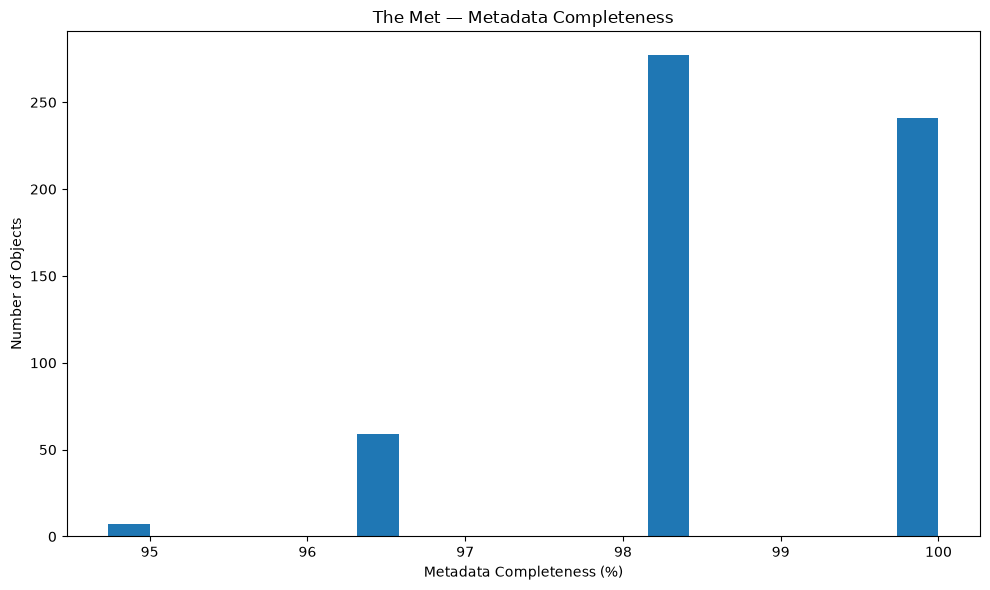

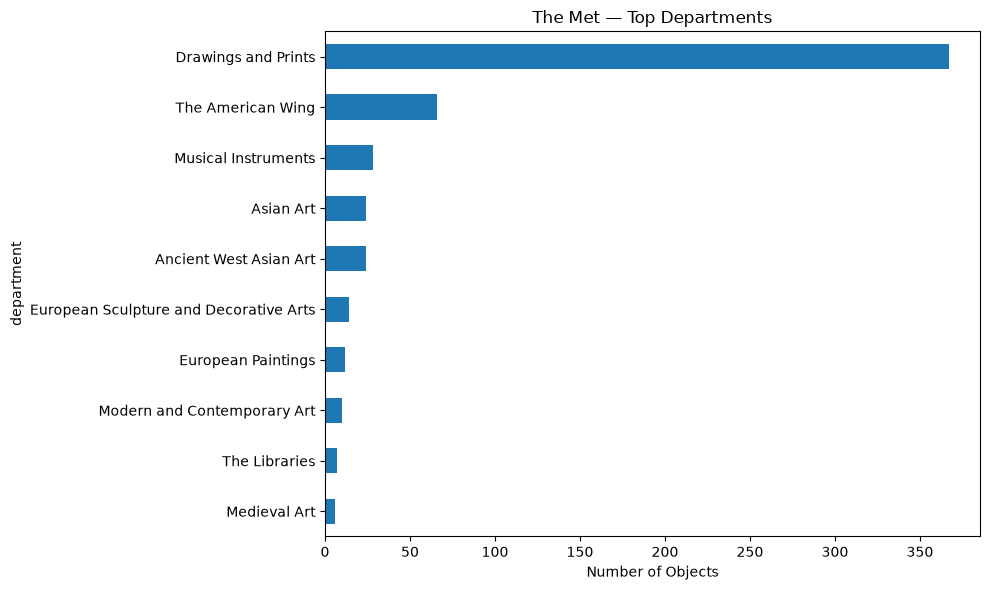

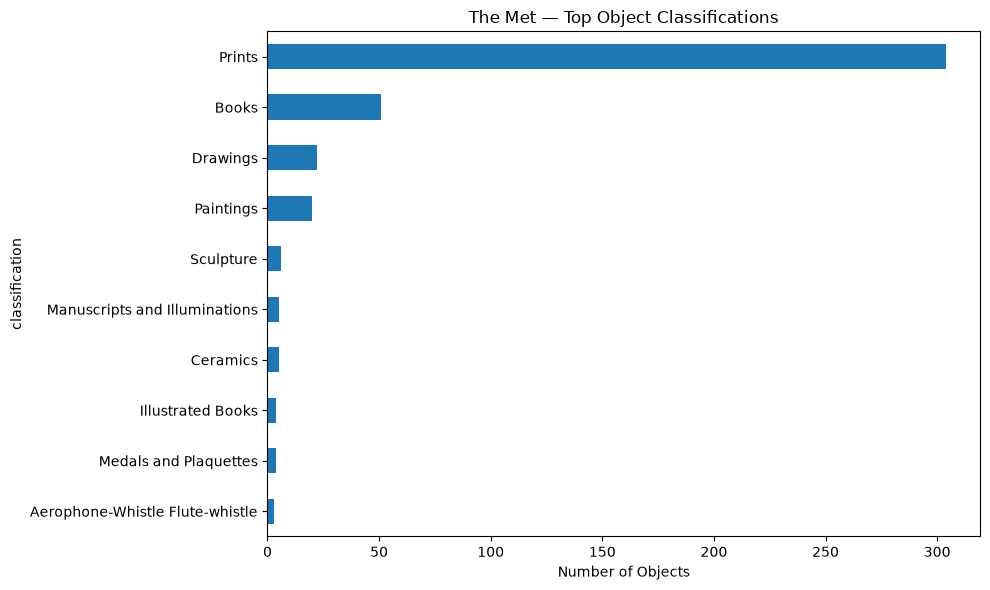

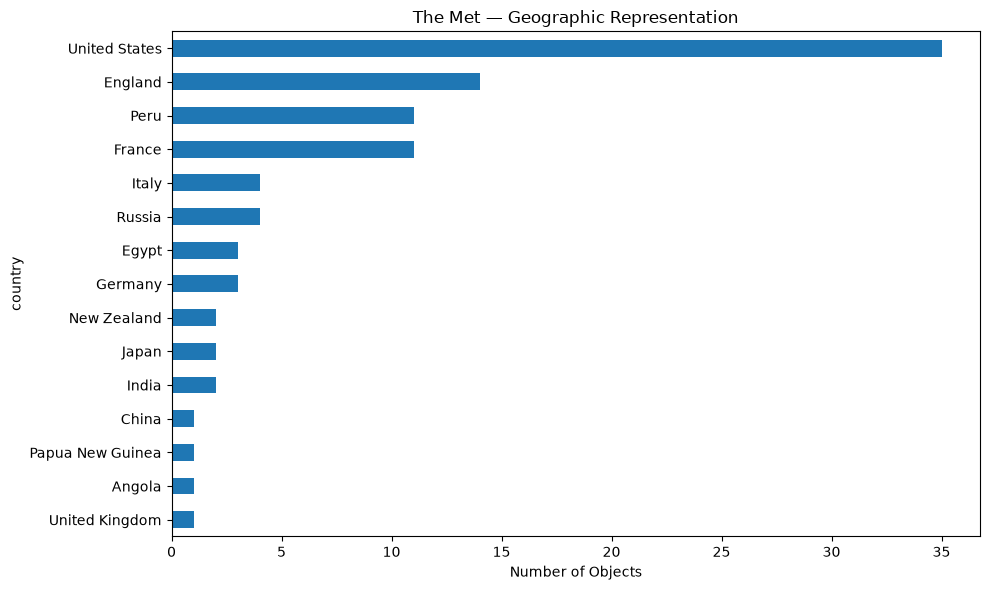

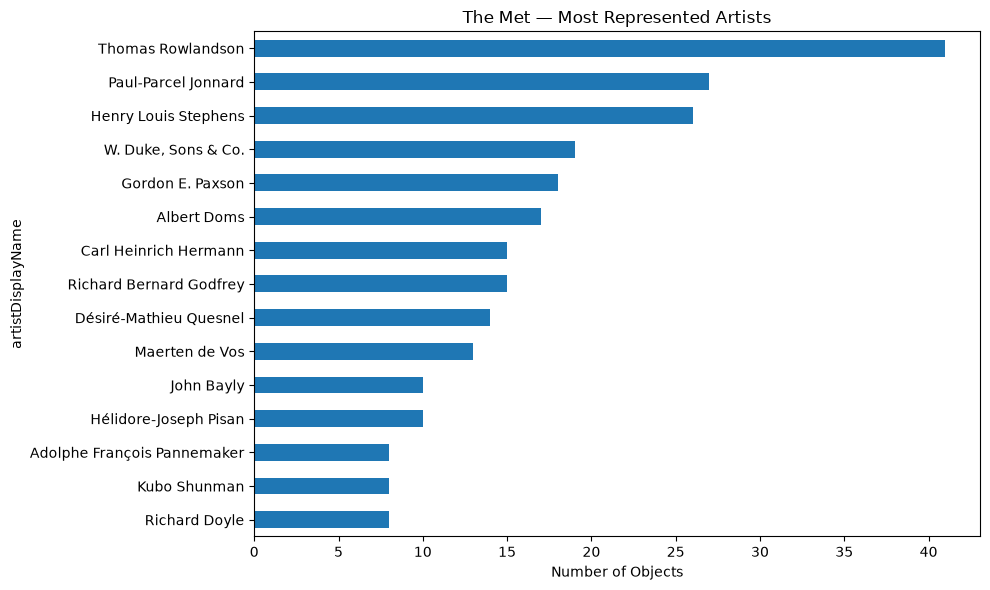



ANALYTICS ENGINE COMPLETE
Final records analyzed: 584
Final fields available: 65


In [15]:
# ============================================================
# HERITAGE INTELLIGENCE
# MILESTONE 2 — COLLECTION ANALYTICS ENGINE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("HERITAGE INTELLIGENCE — COLLECTION ANALYTICS")
print("=" * 70)


# ============================================================
# 1. BASIC COLLECTION OVERVIEW
# ============================================================

print("\n1. COLLECTION OVERVIEW")
print("-" * 70)

print(f"Total records: {len(met_df):,}")
print(f"Total fields: {len(met_df.columns):,}")

if "objectID" in met_df.columns:
    print(
        f"Duplicate object IDs: "
        f"{met_df['objectID'].duplicated().sum():,}"
    )


# ============================================================
# 2. DATA QUALITY
# ============================================================

print("\n2. DATA QUALITY")
print("-" * 70)

missing_count = met_df.isna().sum()

missing_percentage = (
    met_df.isna()
    .mean()
    .mul(100)
    .round(2)
)

data_quality = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_percentage
}).sort_values(
    "missing_percentage",
    ascending=False
)

print(data_quality.head(20))


# ============================================================
# 3. METADATA COMPLETENESS
# ============================================================

print("\n3. METADATA COMPLETENESS")
print("-" * 70)

# Count only empty / missing values.
# Treat empty strings as missing as well.

analysis_df = met_df.copy()

for column in analysis_df.columns:

    if analysis_df[column].dtype == "object":

        analysis_df[column] = analysis_df[column].replace(
            r"^\s*$",
            np.nan,
            regex=True
        )

met_df["metadata_completeness"] = (
    analysis_df.notna().mean(axis=1) * 100
)

print(
    met_df["metadata_completeness"]
    .describe()
    .round(2)
)


# ============================================================
# 4. FIELD-LEVEL ANALYSIS
# ============================================================

print("\n4. IMPORTANT COLLECTION FIELDS")
print("-" * 70)

fields_to_analyze = [
    "department",
    "objectName",
    "classification",
    "culture",
    "period",
    "country",
    "region",
    "medium",
    "artistDisplayName",
    "artistNationality"
]

field_results = {}

for field in fields_to_analyze:

    if field in met_df.columns:

        cleaned = (
            met_df[field]
            .replace("", np.nan)
            .dropna()
        )

        counts = cleaned.value_counts().head(10)

        field_results[field] = counts

        print(f"\n--- {field.upper()} ---")
        print(counts)


# ============================================================
# 5. PUBLIC DOMAIN ANALYSIS
# ============================================================

print("\n5. PUBLIC DOMAIN")
print("-" * 70)

if "isPublicDomain" in met_df.columns:

    print(
        met_df["isPublicDomain"]
        .value_counts(dropna=False)
    )


# ============================================================
# 6. IMAGE AVAILABILITY
# ============================================================

print("\n6. IMAGE AVAILABILITY")
print("-" * 70)

if "primaryImage" in met_df.columns:

    met_df["has_image"] = (
        met_df["primaryImage"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
    )

    print(
        met_df["has_image"]
        .value_counts()
    )


# ============================================================
# 7. WIKIDATA AVAILABILITY
# ============================================================

print("\n7. WIKIDATA AVAILABILITY")
print("-" * 70)

if "objectWikidata_URL" in met_df.columns:

    met_df["has_wikidata"] = (
        met_df["objectWikidata_URL"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
    )

    print(
        met_df["has_wikidata"]
        .value_counts()
    )


# ============================================================
# 8. ARTIST ANALYSIS
# ============================================================

print("\n8. ARTIST ANALYSIS")
print("-" * 70)

if "artistDisplayName" in met_df.columns:

    artist_counts = (
        met_df["artistDisplayName"]
        .replace("", np.nan)
        .dropna()
        .value_counts()
    )

    print("Top 20 artists:")

    print(
        artist_counts.head(20)
    )


# ============================================================
# 9. COUNTRY ANALYSIS
# ============================================================

print("\n9. GEOGRAPHIC ANALYSIS")
print("-" * 70)

if "country" in met_df.columns:

    country_counts = (
        met_df["country"]
        .replace("", np.nan)
        .dropna()
        .value_counts()
    )

    print("Top countries:")

    print(
        country_counts.head(20)
    )


# ============================================================
# 10. HISTORICAL DATE ANALYSIS
# ============================================================

print("\n10. HISTORICAL DATE ANALYSIS")
print("-" * 70)

if "objectBeginDate" in met_df.columns:

    met_df["objectBeginDate_numeric"] = pd.to_numeric(
        met_df["objectBeginDate"],
        errors="coerce"
    )

    print(
        met_df["objectBeginDate_numeric"]
        .describe()
        .round(2)
    )


# ============================================================
# 11. CENTURY ANALYSIS
# ============================================================

print("\n11. HISTORICAL PERIOD / CENTURY")
print("-" * 70)

if "objectBeginDate_numeric" in met_df.columns:

    def calculate_century(year):

        if pd.isna(year):
            return np.nan

        year = int(year)

        if year > 0:
            return ((year - 1) // 100) + 1

        return np.nan


    met_df["century"] = (
        met_df["objectBeginDate_numeric"]
        .apply(calculate_century)
    )

    print(
        met_df["century"]
        .value_counts()
        .head(20)
    )


# ============================================================
# 12. CORE METADATA REVIEW
# ============================================================

print("\n12. RECORDS REQUIRING ATTENTION")
print("-" * 70)

required_fields = [
    "title",
    "objectDate",
    "culture",
    "country",
    "medium",
    "artistDisplayName",
    "primaryImage"
]

available_required_fields = [
    field
    for field in required_fields
    if field in met_df.columns
]

missing_core = (
    analysis_df[available_required_fields]
    .isna()
    .sum(axis=1)
)

met_df["missing_core_fields"] = missing_core


def assign_priority(value):

    if value >= 5:
        return "High"

    elif value >= 2:
        return "Medium"

    return "Low"


met_df["review_priority"] = (
    met_df["missing_core_fields"]
    .apply(assign_priority)
)

print(
    met_df["review_priority"]
    .value_counts()
)


# ============================================================
# 13. COLLECTION HEALTH SCORE
# ============================================================

print("\n13. COLLECTION HEALTH SCORE")
print("-" * 70)

# Metadata completeness = 70%
completeness_score = (
    met_df["metadata_completeness"]
)


# Image availability = 15%

if "has_image" in met_df.columns:

    image_score = (
        met_df["has_image"]
        .astype(int)
        * 100
    )

else:

    image_score = 0


# Wikidata availability = 15%

if "has_wikidata" in met_df.columns:

    wikidata_score = (
        met_df["has_wikidata"]
        .astype(int)
        * 100
    )

else:

    wikidata_score = 0


met_df["collection_health_score"] = (
    completeness_score * 0.70
    + image_score * 0.15
    + wikidata_score * 0.15
)


print(
    met_df["collection_health_score"]
    .describe()
    .round(2)
)


# ============================================================
# 14. SAVE ANALYZED DATASET
# ============================================================

met_df.to_csv(
    "../data/processed/met_collection_analyzed.csv",
    index=False
)

print("\nAnalyzed dataset saved.")


# ============================================================
# 15. VISUALIZATION — COMPLETENESS
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    met_df["metadata_completeness"],
    bins=20
)

plt.title(
    "The Met — Metadata Completeness"
)

plt.xlabel(
    "Metadata Completeness (%)"
)

plt.ylabel(
    "Number of Objects"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. VISUALIZATION — DEPARTMENTS
# ============================================================

if "department" in met_df.columns:

    top_departments = (
        met_df["department"]
        .replace("", np.nan)
        .dropna()
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(10, 6))

    top_departments.sort_values().plot(
        kind="barh"
    )

    plt.title(
        "The Met — Top Departments"
    )

    plt.xlabel(
        "Number of Objects"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 17. VISUALIZATION — CLASSIFICATIONS
# ============================================================

if "classification" in met_df.columns:

    top_classifications = (
        met_df["classification"]
        .replace("", np.nan)
        .dropna()
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(10, 6))

    top_classifications.sort_values().plot(
        kind="barh"
    )

    plt.title(
        "The Met — Top Object Classifications"
    )

    plt.xlabel(
        "Number of Objects"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 18. VISUALIZATION — COUNTRIES
# ============================================================

if "country" in met_df.columns:

    top_countries = (
        met_df["country"]
        .replace("", np.nan)
        .dropna()
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(10, 6))

    top_countries.sort_values().plot(
        kind="barh"
    )

    plt.title(
        "The Met — Geographic Representation"
    )

    plt.xlabel(
        "Number of Objects"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 19. VISUALIZATION — ARTISTS
# ============================================================

if "artistDisplayName" in met_df.columns:

    top_artists = (
        met_df["artistDisplayName"]
        .replace("", np.nan)
        .dropna()
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(10, 6))

    top_artists.sort_values().plot(
        kind="barh"
    )

    plt.title(
        "The Met — Most Represented Artists"
    )

    plt.xlabel(
        "Number of Objects"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# COMPLETE
# ============================================================

print("\n")
print("=" * 70)
print("ANALYTICS ENGINE COMPLETE")
print("=" * 70)

print(
    f"Final records analyzed: {len(met_df):,}"
)

print(
    f"Final fields available: {len(met_df.columns):,}"
)